# Exploratory Data Analysis — Student Performance (Mathematics)



## Purpose

This notebook covers the **EDA responsibility only**. The objective is to understand the structure, quality, distributions, relationships, and risk-target implications in the Mathematics student-performance dataset before downstream preprocessing and model development.

The project document defines the business focus as **At Risk Student Identification**. It states that the final Mathematics grade `G3` is used to construct the `Risk Status` target, while `G3` must not be used as a predictor in the eventual classification model.

### EDA questions

1. What does the dataset contain and what are the variable types?
2. Are there missing, duplicate, inconsistent, or suspicious observations?
3. What are the distributions of the important academic, demographic, behavioural, and social variables?
4. How are `G1`, `G2`, and `G3` distributed?
5. How does the choice of a risk threshold change the target-class balance?
6. Which variables appear associated with final Mathematics performance?
7. What patterns distinguish students below candidate risk thresholds?
8. What evidence should be passed to data preparation and model development?

> **Important:** EDA may use `G3` to study the outcome and justify a risk threshold. It is **not** treated as a model input here. The project document explicitly warns that including `G3` as a predictor would cause target leakage.

In [1]:
# ============================================================
# 1. Imports and plotting configuration
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, pointbiserialr, chi2_contingency

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# ============================================================
# 2. Load the Mathematics dataset
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# Update the path below if you placed student-mat.csv in a subfolder.
# Default assumes the file is in the root of My Drive.
DATA_PATH = '/content/drive/My Drive/student-mat.csv'

# UCI's student-mat.csv is semicolon-separated.
df = pd.read_csv(DATA_PATH, sep=';')

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: 395 rows x 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


## 1. Dataset overview

The actual file contains **395 student records and 33 variables**. Each row represents one student, matching the project document's stated unit of analysis. fileciteturn0file0L154-L160

The dataset contains academic, demographic, social, and behavioural information. The three Mathematics grades are particularly important:

- `G1` — first-period Mathematics grade
- `G2` — second-period Mathematics grade
- `G3` — final Mathematics grade

The project uses earlier information to predict a risk category associated with the final grade. fileciteturn0file0L161-L173

In [3]:
# ============================================================
# 3. Structural inspection
# ============================================================
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

Shape: (395, 33)

Data types:
             dtype
school      object
sex         object
age          int64
address     object
famsize     object
Pstatus     object
Medu         int64
Fedu         int64
Mjob        object
Fjob        object
reason      object
guardian    object
traveltime   int64
studytime    int64
failures     int64
schoolsup   object
famsup      object
paid        object
activities  object
nursery     object
higher      object
internet    object
romantic    object
famrel       int64
freetime     int64
goout        int64
Dalc         int64
Walc         int64
health       int64
absences     int64
G1           int64
G2           int64
G3           int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int6

In [4]:
# Variable-level summary: type, unique values, missingness
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean().mul(100).round(2)
}).sort_values(["dtype", "n_unique"])

print(overview)

             dtype  n_unique  missing  missing_%
traveltime   int64         4        0        0.0
studytime    int64         4        0        0.0
failures     int64         4        0        0.0
Medu         int64         5        0        0.0
Fedu         int64         5        0        0.0
famrel       int64         5        0        0.0
freetime     int64         5        0        0.0
goout        int64         5        0        0.0
Dalc         int64         5        0        0.0
Walc         int64         5        0        0.0
health       int64         5        0        0.0
age          int64         8        0        0.0
G1           int64        17        0        0.0
G2           int64        17        0        0.0
G3           int64        18        0        0.0
absences     int64        34        0        0.0
school      object         2        0        0.0
sex         object         2        0        0.0
address     object         2        0        0.0
famsize     object  

### Why this EDA matters

This establishes the schema before any transformation. In particular, it prevents us from treating every variable as continuous: several variables are categorical or ordered rating variables and need different downstream handling.

The project document also says the exact predictor set should only be finalized after EDA, feature analysis, preprocessing, and checking whether variables are available at prediction time. fileciteturn0file0L150-L153

## 2. Data quality assessment

The first quality checks are missing values, duplicate records, and basic value validity. We should not remove observations merely because they look unusual; an unusual student can be a legitimate observation.

In [5]:
# ============================================================
# 4. Missing values and duplicates
# ============================================================
missing = df.isna().sum().sort_values(ascending=False)
print("Total missing cells:", int(df.isna().sum().sum()))
print(missing[missing > 0].to_frame("missing_count"))

print("Exact duplicate rows:", int(df.duplicated().sum()))

Total missing cells: 0
Empty DataFrame
Columns: [missing_count]
Index: []
Exact duplicate rows: 0


In [6]:
# ============================================================
# 5. Categorical value inspection
# ============================================================
for col in df.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).to_frame("count"))


--- school ---
        count
school       
GP        349
MS         46

--- sex ---
     count
sex       
F      208
M      187

--- address ---
         count
address       
U          307
R           88

--- famsize ---
         count
famsize       
GT3        281
LE3        114

--- Pstatus ---
         count
Pstatus       
T          354
A           41

--- Mjob ---
          count
Mjob           
other       141
services    103
at_home      59
teacher      58
health       34

--- Fjob ---
          count
Fjob           
other       217
services    111
teacher      29
at_home      20
health       18

--- reason ---
            count
reason           
course        145
home          109
reputation    105
other          36

--- guardian ---
          count
guardian       
mother      273
father       90
other        32

--- schoolsup ---
           count
schoolsup       
no           344
yes           51

--- famsup ---
        count
famsup       
yes       242
no        153

--- pa

### Quality finding

The notebook should report the executed result rather than assuming a problem exists. For this file, the initial inspection shows **no missing cells and no exact duplicate rows**. Therefore, there is no evidence here requiring blanket imputation or duplicate deletion.

Categorical-value inspection is still necessary because inconsistent spelling/casing or unexpected categories can silently create extra levels.

In [7]:
# ============================================================
# 6. Domain/range checks for numeric variables
# ============================================================
expected_ranges = {
    "age": (15, 22),
    "Medu": (0, 4),
    "Fedu": (0, 4),
    "traveltime": (1, 4),
    "studytime": (1, 4),
    "failures": (0, 3),
    "famrel": (1, 5),
    "freetime": (1, 5),
    "goout": (1, 5),
    "Dalc": (1, 5),
    "Walc": (1, 5),
    "health": (1, 5),
    "absences": (0, np.inf),
    "G1": (0, 20),
    "G2": (0, 20),
    "G3": (0, 20),
}

range_results = []
for col, (low, high) in expected_ranges.items():
    if col in df.columns:
        invalid = ((df[col] < low) | (df[col] > high)).sum()
        range_results.append({
            "variable": col,
            "expected_min": low,
            "expected_max": high,
            "observed_min": df[col].min(),
            "observed_max": df[col].max(),
            "invalid_count": int(invalid)
        })

range_check = pd.DataFrame(range_results)
print(range_check)

      variable  expected_min  expected_max  observed_min  observed_max  \
0          age            15          22.0            15            22   
1         Medu             0           4.0             0             4   
2         Fedu             0           4.0             0             4   
3   traveltime             1           4.0             1             4   
4    studytime             1           4.0             1             4   
5     failures             0           3.0             0             3   
6       famrel             1           5.0             1             5   
7     freetime             1           5.0             1             5   
8        goout             1           5.0             1             5   
9         Dalc             1           5.0             1             5   
10        Walc             1           5.0             1             5   
11      health             1           5.0             1             5   
12    absences             0          

### Interpretation of range checks

Range validation is preferable to deleting outliers automatically. For example, `absences` can legitimately be much larger than the typical student value. An extreme value should only be removed if there is evidence that it is erroneous.

This distinction is important because the dataset is relatively small; unnecessary deletion can remove real information.

# 3. Descriptive statistics

We now summarize the numerical variables and inspect the shape of important distributions. Descriptive statistics help identify central tendency, spread, skewness, and possible unusual values before modelling.

In [8]:
# ============================================================
# 7. Descriptive statistics
# ============================================================
print(df.describe().T.round(2))

            count   mean   std   min   25%   50%   75%   max
age         395.0  16.70  1.28  15.0  16.0  17.0  18.0  22.0
Medu        395.0   2.75  1.09   0.0   2.0   3.0   4.0   4.0
Fedu        395.0   2.52  1.09   0.0   2.0   2.0   3.0   4.0
traveltime  395.0   1.45  0.70   1.0   1.0   1.0   2.0   4.0
studytime   395.0   2.04  0.84   1.0   1.0   2.0   2.0   4.0
failures    395.0   0.33  0.74   0.0   0.0   0.0   0.0   3.0
famrel      395.0   3.94  0.90   1.0   4.0   4.0   5.0   5.0
freetime    395.0   3.24  1.00   1.0   3.0   3.0   4.0   5.0
goout       395.0   3.11  1.11   1.0   2.0   3.0   4.0   5.0
Dalc        395.0   1.48  0.89   1.0   1.0   1.0   2.0   5.0
Walc        395.0   2.29  1.29   1.0   1.0   2.0   3.0   5.0
health      395.0   3.55  1.39   1.0   3.0   4.0   5.0   5.0
absences    395.0   5.71  8.00   0.0   0.0   4.0   8.0  75.0
G1          395.0  10.91  3.32   3.0   8.0  11.0  13.0  19.0
G2          395.0  10.71  3.76   0.0   9.0  11.0  13.0  19.0
G3          395.0  10.42

In [9]:
# ============================================================
# 8. Skewness analysis
# ============================================================
numeric_skew = (
    df.select_dtypes(include=np.number)
      .skew()
      .sort_values(key=lambda s: s.abs(), ascending=False)
      .to_frame("skewness")
)

print(numeric_skew.round(3))

            skewness
absences       3.672
failures       2.387
Dalc           2.191
traveltime     1.607
famrel        -0.952
G3            -0.733
studytime      0.632
Walc           0.612
health        -0.495
age            0.466
G2            -0.432
Medu          -0.318
G1             0.241
freetime      -0.163
goout          0.117
Fedu          -0.032


### Why skewness matters

Strongly skewed variables can influence statistical summaries and some modelling approaches. `absences` is especially worth inspecting because attendance counts are non-negative and may have a long right tail.

We should **inspect** skewness rather than automatically log-transforming or clipping every skewed feature. The transformation decision belongs to preprocessing/model development and should be evaluated using the training data.

# 4. Univariate EDA — numerical and ordinal variables

Histograms show the empirical distribution, while boxplots help reveal spread and potential extreme observations. These plots are useful for identifying variables that may need special consideration downstream.

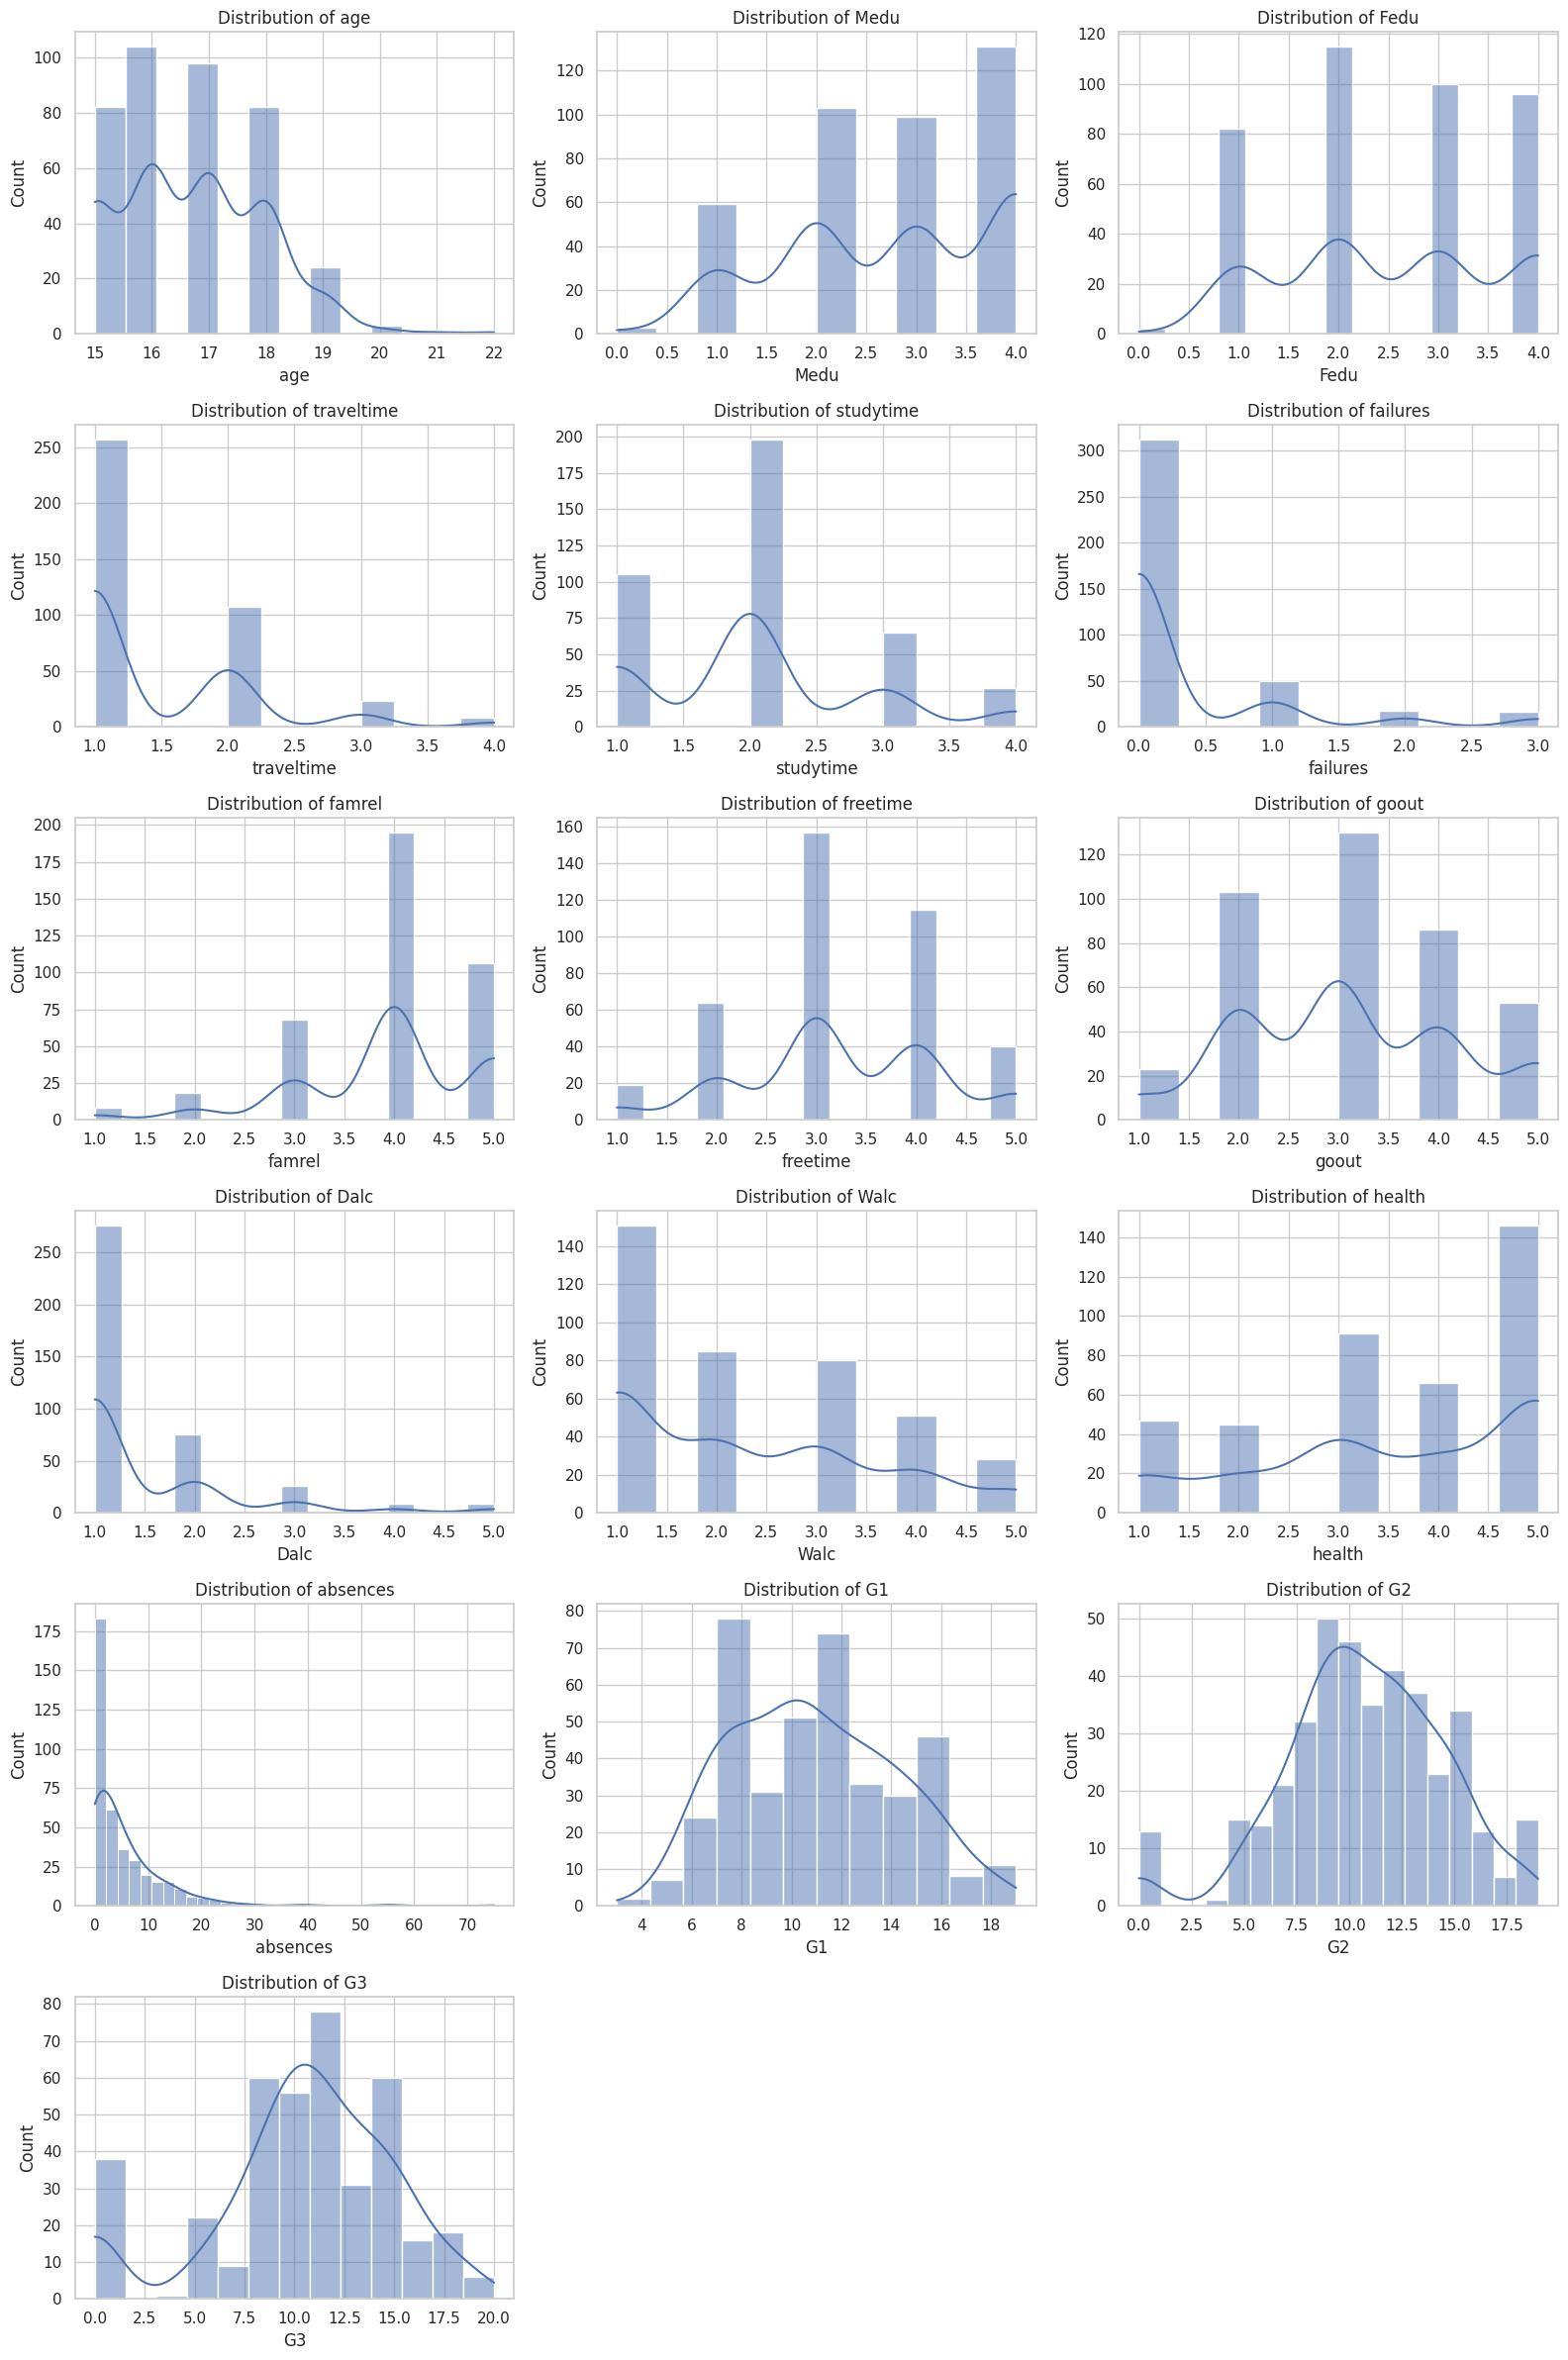

In [10]:
# ============================================================
# 9. Histograms for all numerical variables
# ============================================================
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

ncols = 3
nrows = int(np.ceil(len(numeric_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)

for ax in axes[len(numeric_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

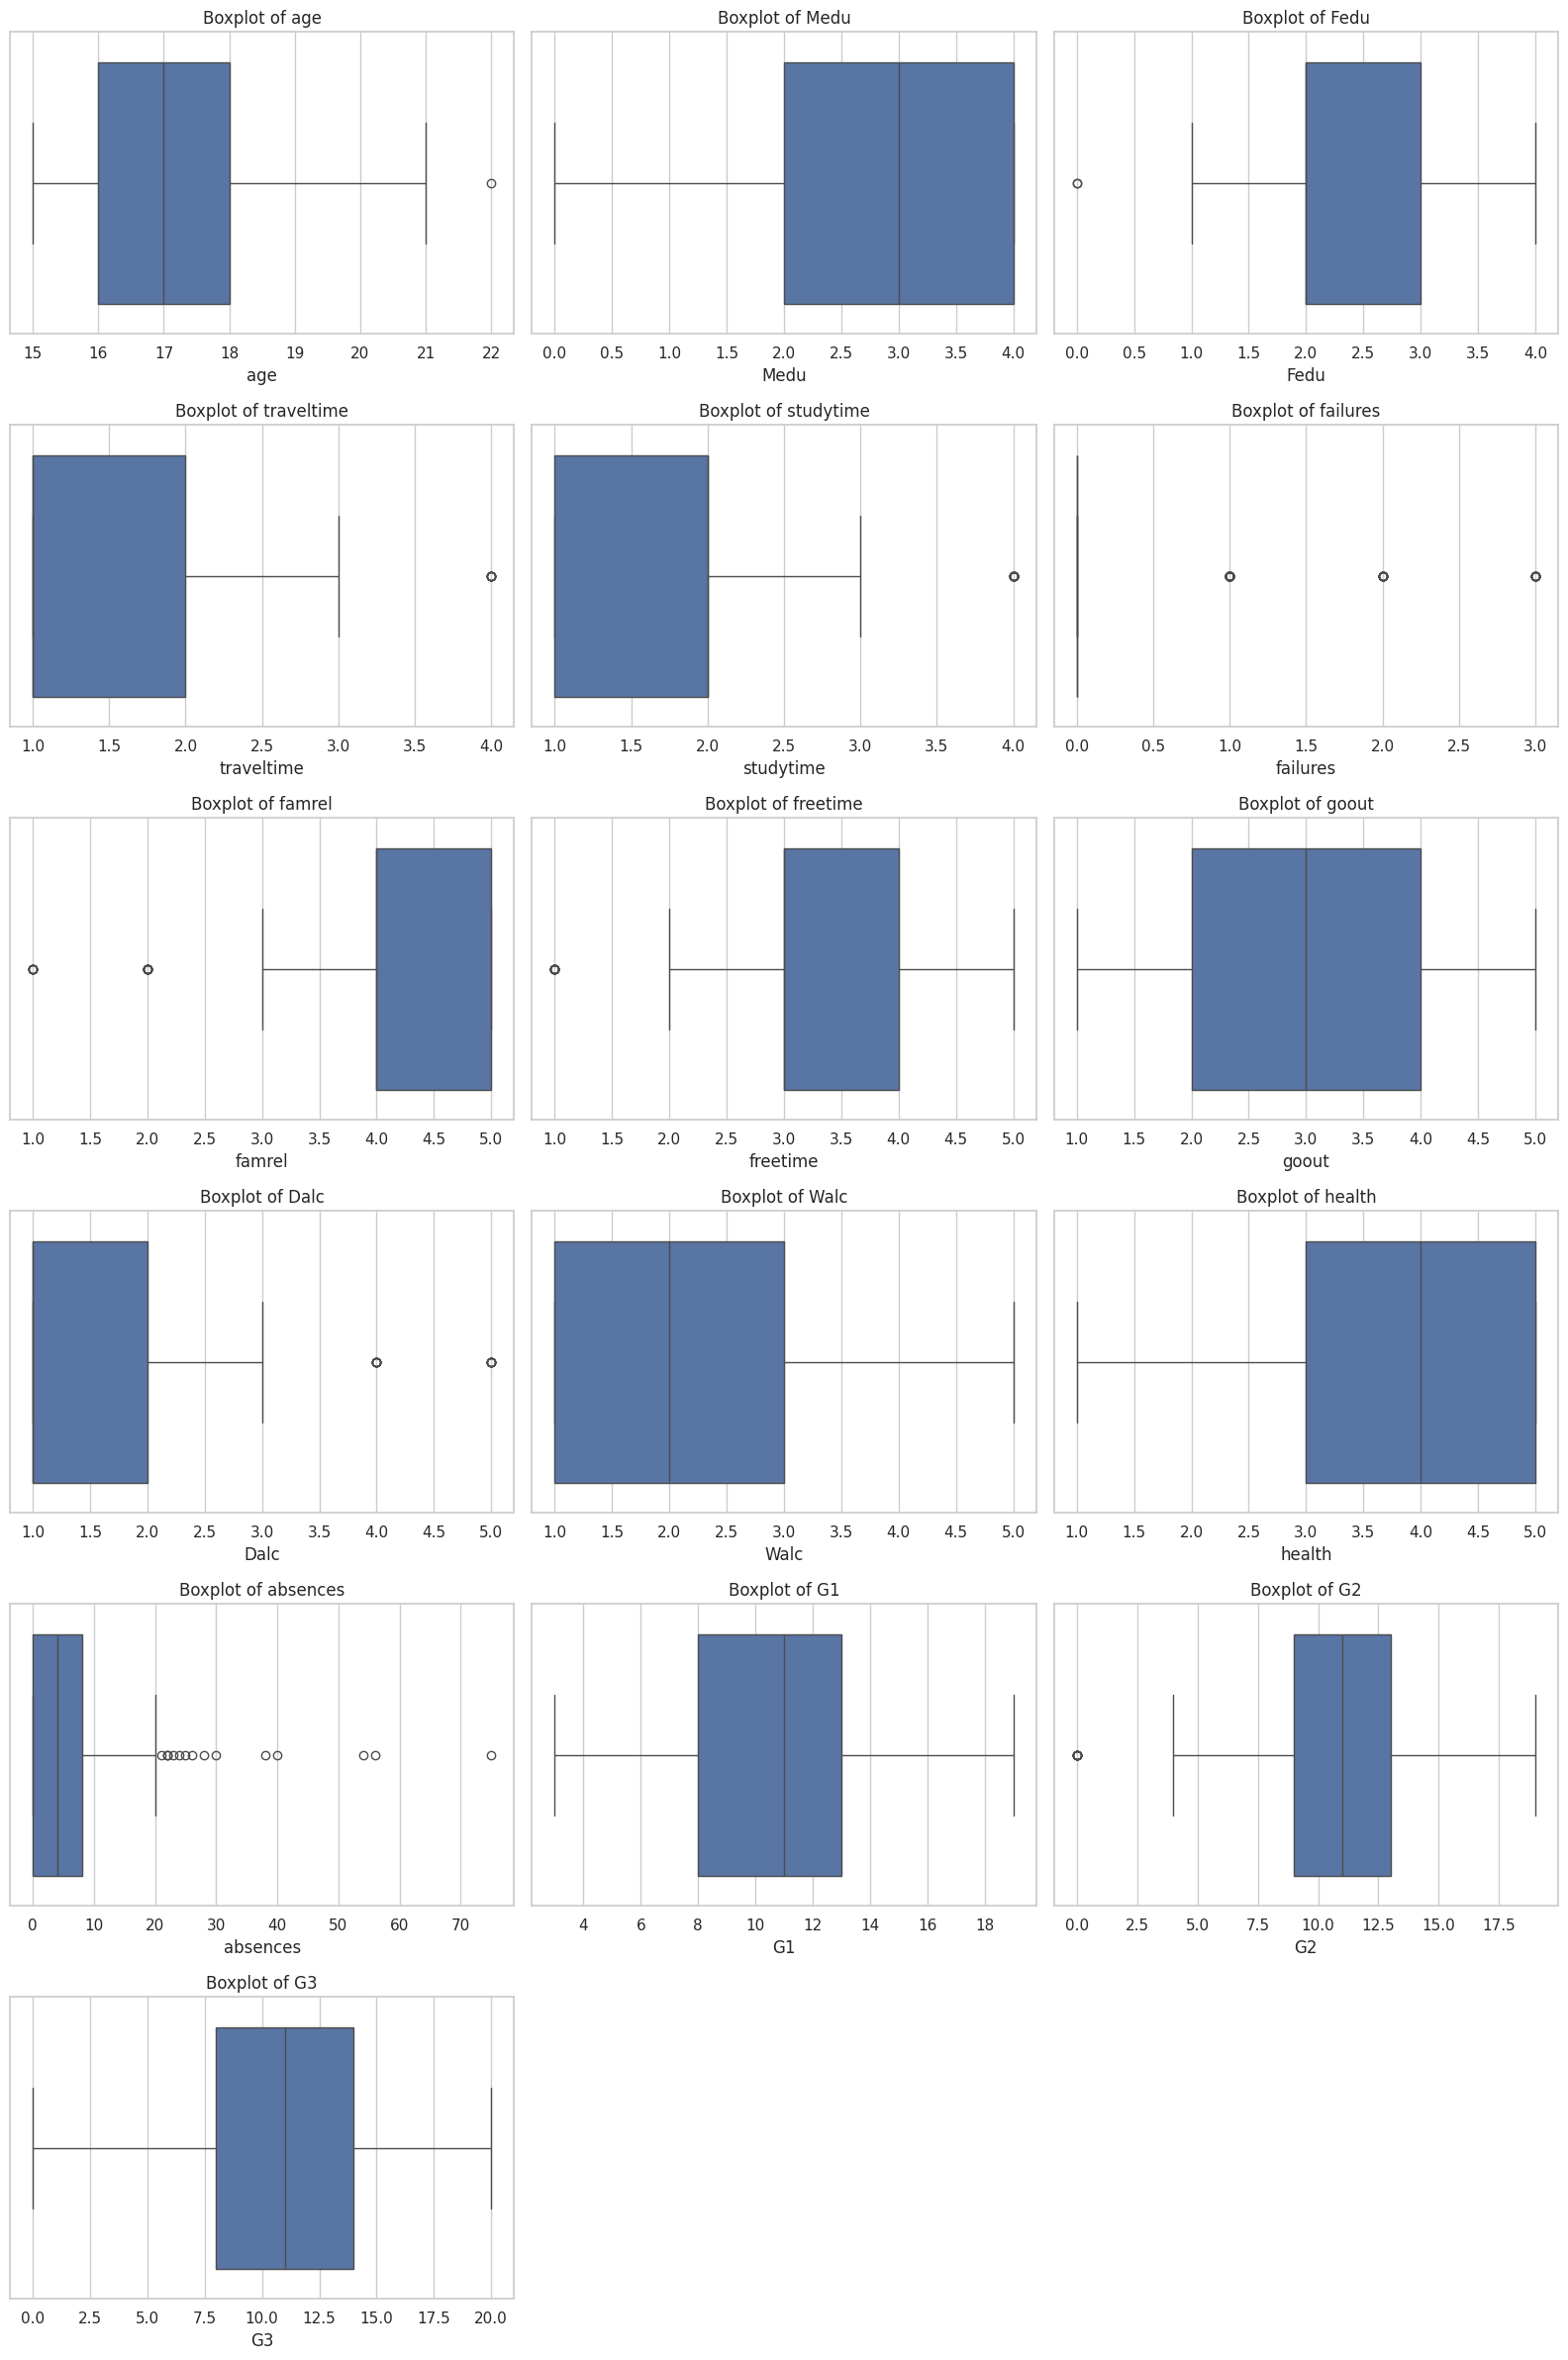

In [11]:
# ============================================================
# 10. Boxplots for numerical variables
# ============================================================
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")
    ax.set_xlabel(col)

for ax in axes[len(numeric_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

### Interpretation guidance

- Concentrated ordinal variables are expected because many are ratings on short scales.
- `G1`, `G2`, and `G3` deserve special attention because they represent sequential academic performance.
- `absences` should be checked for right-skew and extreme but potentially legitimate observations.

# 5. Univariate EDA — categorical variables

Frequency plots show the composition of the student population for categorical attributes. These are important because an apparently strong relationship can be misleading when a category has very few observations.


school
        count  percentage
school                   
GP        349       88.35
MS         46       11.65


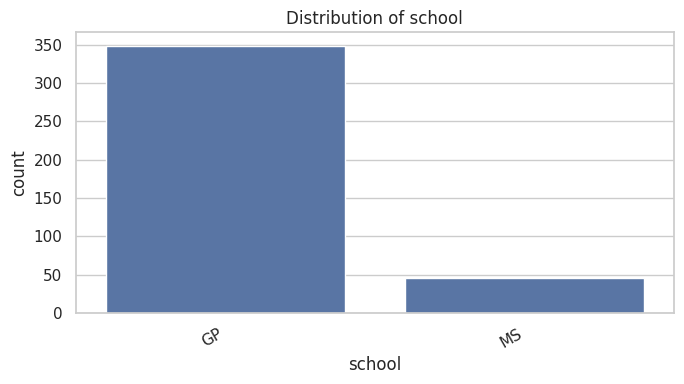


sex
     count  percentage
sex                   
F      208       52.66
M      187       47.34


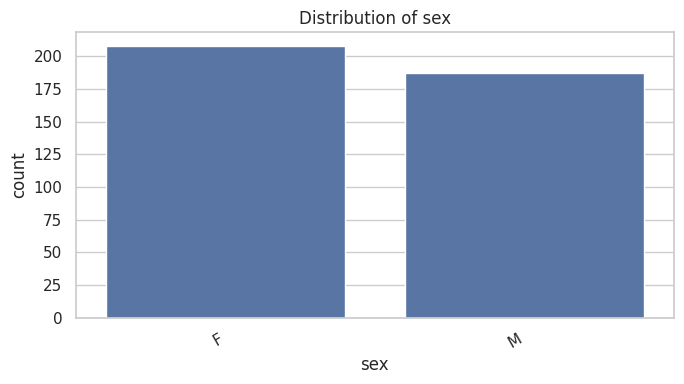


address
         count  percentage
address                   
U          307       77.72
R           88       22.28


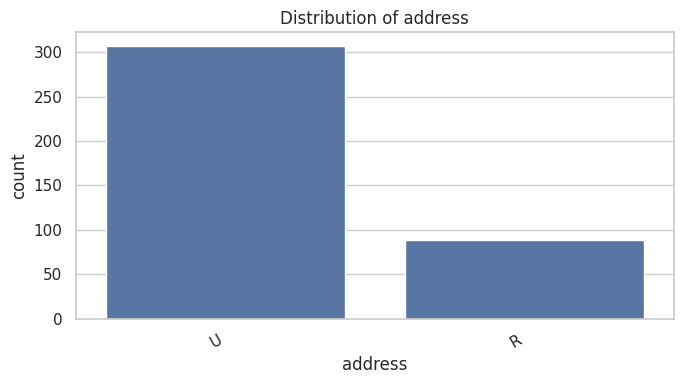


famsize
         count  percentage
famsize                   
GT3        281       71.14
LE3        114       28.86


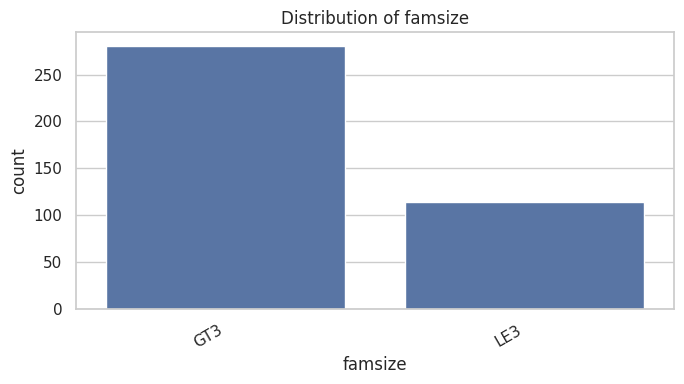


Pstatus
         count  percentage
Pstatus                   
T          354       89.62
A           41       10.38


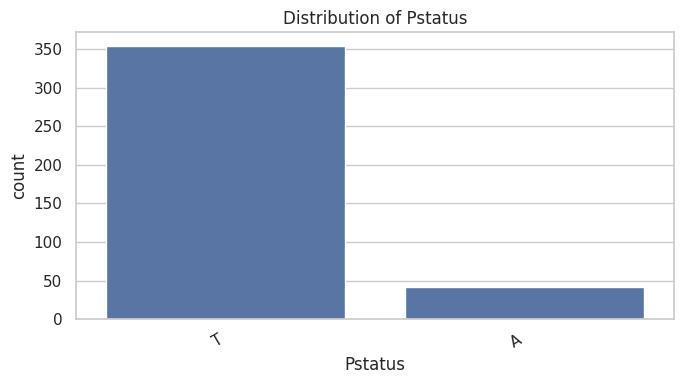


Mjob
          count  percentage
Mjob                       
other       141       35.70
services    103       26.08
at_home      59       14.94
teacher      58       14.68
health       34        8.61


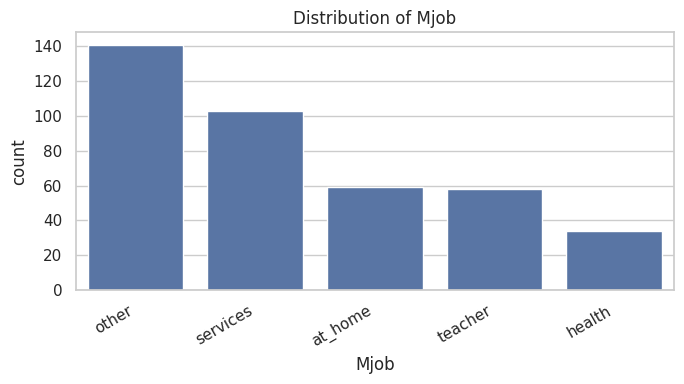


Fjob
          count  percentage
Fjob                       
other       217       54.94
services    111       28.10
teacher      29        7.34
at_home      20        5.06
health       18        4.56


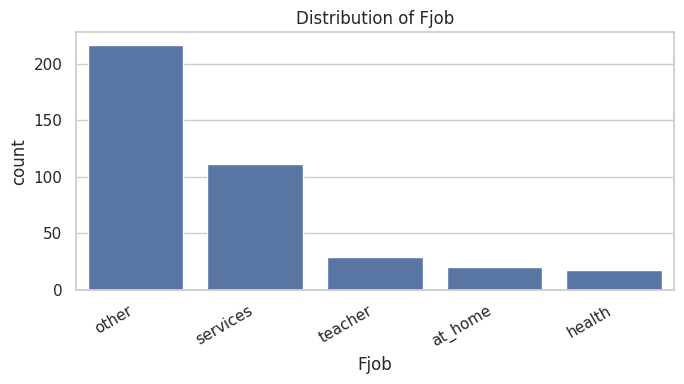


reason
            count  percentage
reason                       
course        145       36.71
home          109       27.59
reputation    105       26.58
other          36        9.11


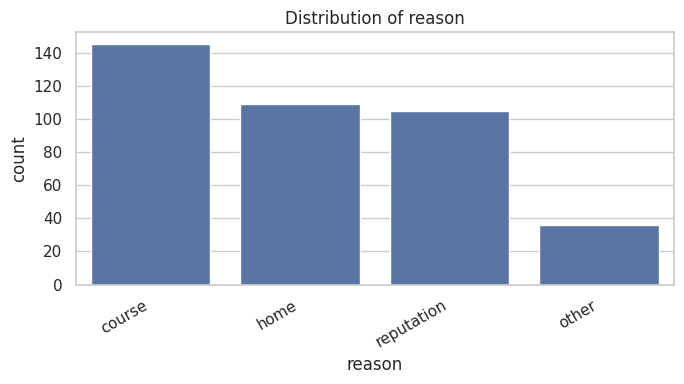


guardian
          count  percentage
guardian                   
mother      273       69.11
father       90       22.78
other        32        8.10


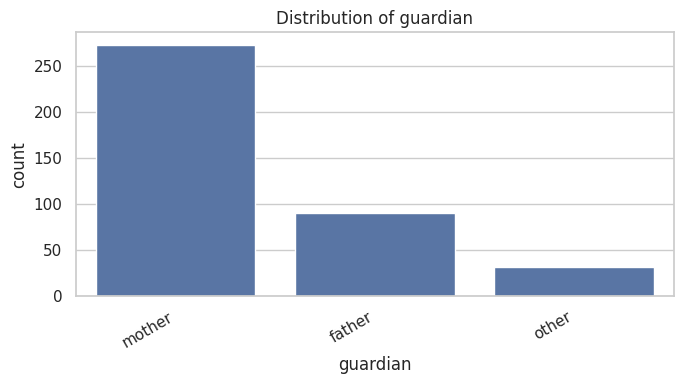


schoolsup
           count  percentage
schoolsup                   
no           344       87.09
yes           51       12.91


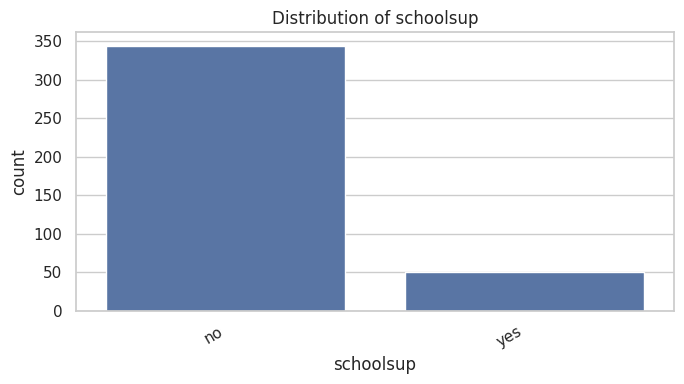


famsup
        count  percentage
famsup                   
yes       242       61.27
no        153       38.73


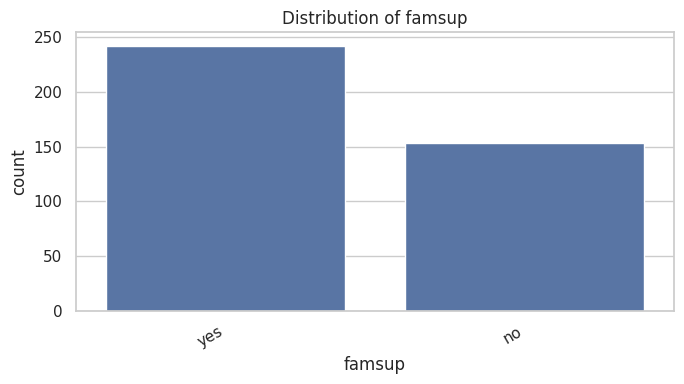


paid
      count  percentage
paid                   
no      214       54.18
yes     181       45.82


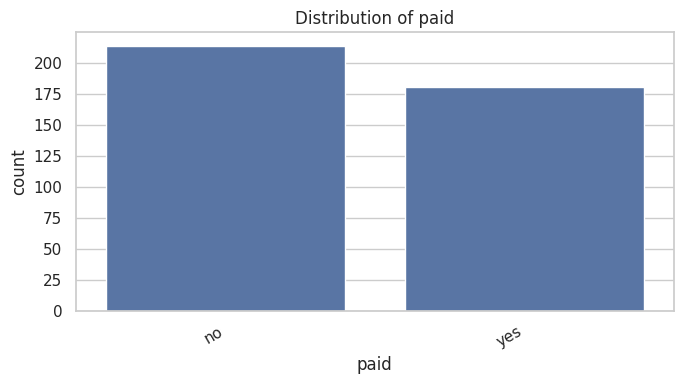


activities
            count  percentage
activities                   
yes           201       50.89
no            194       49.11


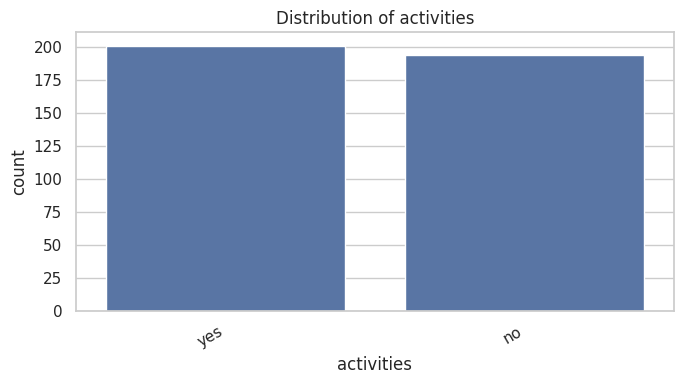


nursery
         count  percentage
nursery                   
yes        314       79.49
no          81       20.51


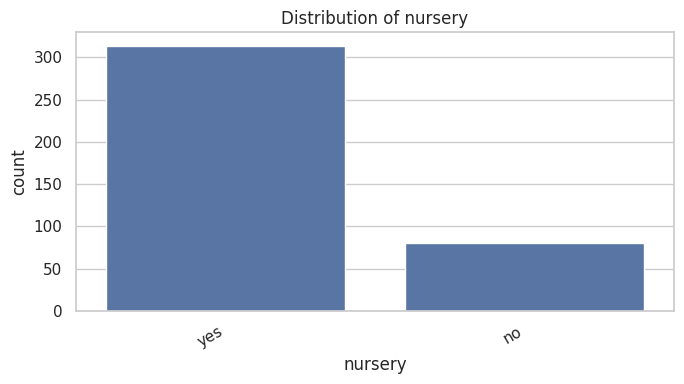


higher
        count  percentage
higher                   
yes       375       94.94
no         20        5.06


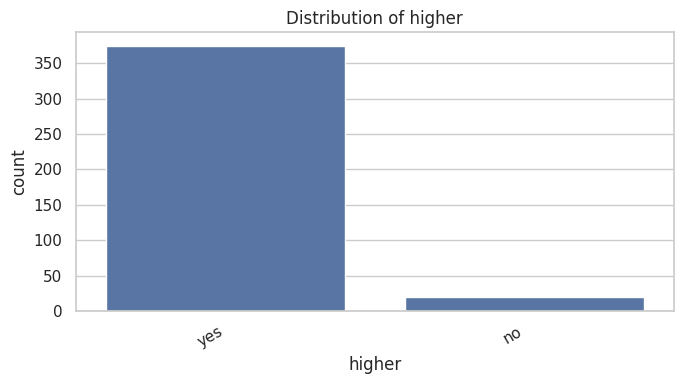


internet
          count  percentage
internet                   
yes         329       83.29
no           66       16.71


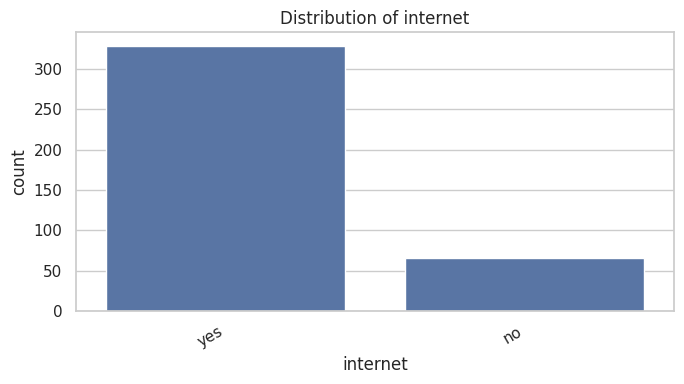


romantic
          count  percentage
romantic                   
no          263       66.58
yes         132       33.42


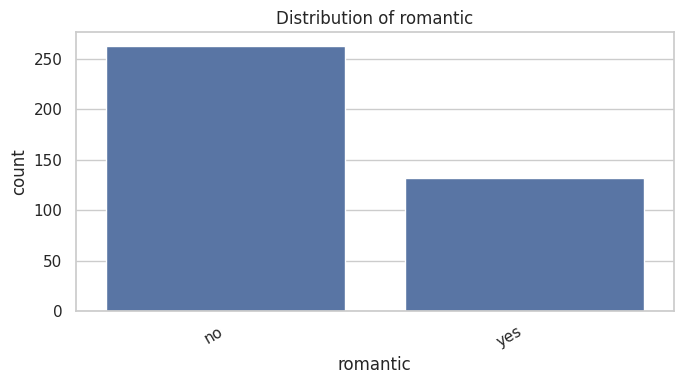

In [12]:
# ============================================================
# 11. Frequency tables and plots for categorical variables
# ============================================================
categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    print(f"\n{col}")
    print(pd.DataFrame({
        "count": counts,
        "percentage": (counts / len(df) * 100).round(2)
    }))

    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, order=counts.index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

### What to look for

For each categorical feature, look for:

- dominant versus minority categories;
- categories with very small counts;
- possible imbalance that could make group comparisons unstable.

This is descriptive evidence only; it does not establish causation.

# 6. Academic performance EDA

The business problem is specifically about final Mathematics performance. Therefore, `G1`, `G2`, and `G3` receive dedicated analysis.

The project document defines `G1` and `G2` as grades available before the final grade and `G3` as the final Mathematics grade used to define the risk target. fileciteturn0file0L161-L163

In [13]:
# ============================================================
# 12. G1, G2, G3 descriptive statistics
# ============================================================
grades = ["G1", "G2", "G3"]

grade_summary = df[grades].agg(
    ["count", "mean", "median", "std", "min", "max"]
).T.round(2)

print(grade_summary)

    count   mean  median   std  min   max
G1  395.0  10.91    11.0  3.32  3.0  19.0
G2  395.0  10.71    11.0  3.76  0.0  19.0
G3  395.0  10.42    11.0  4.58  0.0  20.0


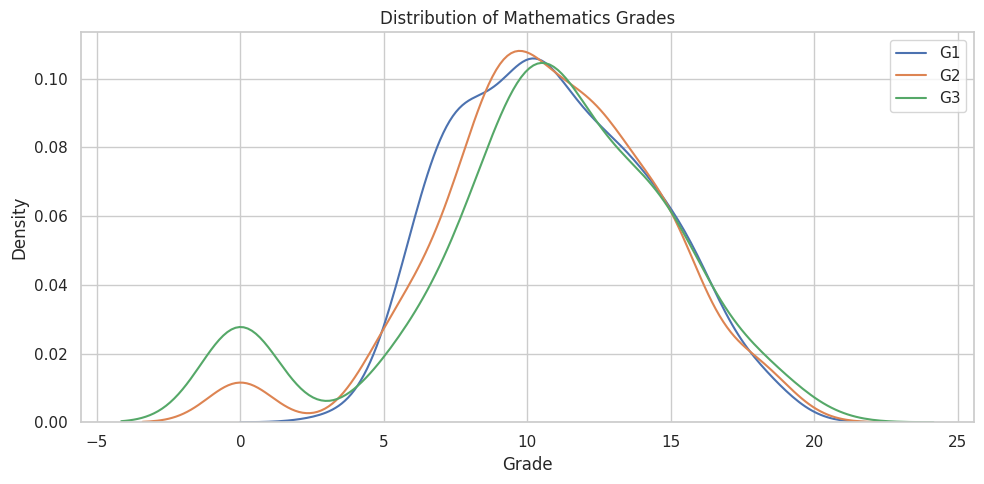

In [14]:
# ============================================================
# 13. Grade distributions
# ============================================================
plt.figure(figsize=(10, 5))
for col in grades:
    sns.kdeplot(df[col], label=col, fill=False)
plt.title("Distribution of Mathematics Grades")
plt.xlabel("Grade")
plt.legend()
plt.tight_layout()
plt.show()

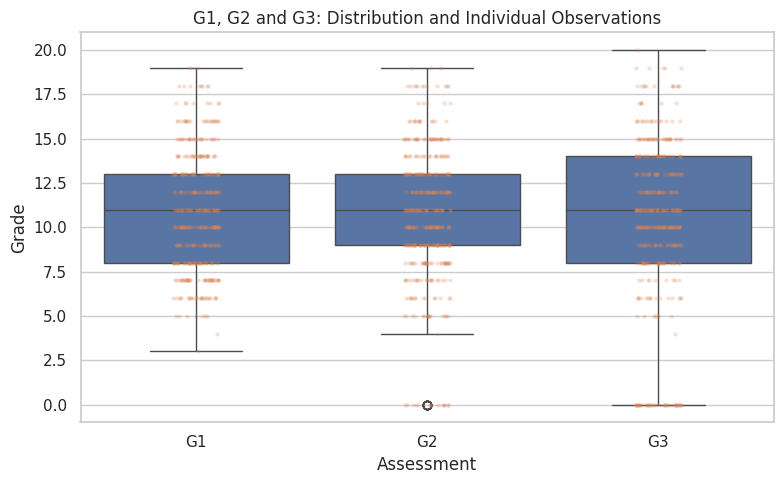

In [15]:
# ============================================================
# 14. Grade-by-grade boxplots
# ============================================================
grade_long = df[grades].melt(var_name="Assessment", value_name="Grade")

plt.figure(figsize=(8, 5))
sns.boxplot(data=grade_long, x="Assessment", y="Grade")
sns.stripplot(data=grade_long, x="Assessment", y="Grade", alpha=0.25, size=3)
plt.title("G1, G2 and G3: Distribution and Individual Observations")
plt.tight_layout()
plt.show()

## Grade progression

A particularly useful question is whether performance in `G1` and `G2` is associated with `G3`. This directly tests whether earlier academic performance contains useful predictive information, which is central to the project's proposed workflow.

       G1     G2     G3
G1  1.000  0.852  0.801
G2  0.852  1.000  0.905
G3  0.801  0.905  1.000


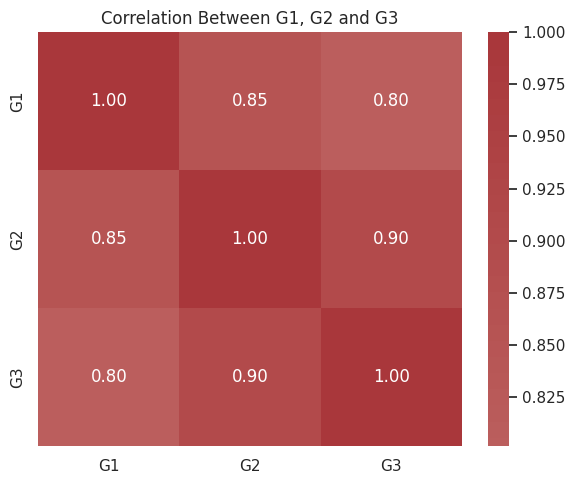

In [16]:
# ============================================================
# 15. Grade correlations
# ============================================================
grade_corr = df[grades].corr()
print(grade_corr.round(3))

plt.figure(figsize=(6, 5))
sns.heatmap(grade_corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Between G1, G2 and G3")
plt.tight_layout()
plt.show()

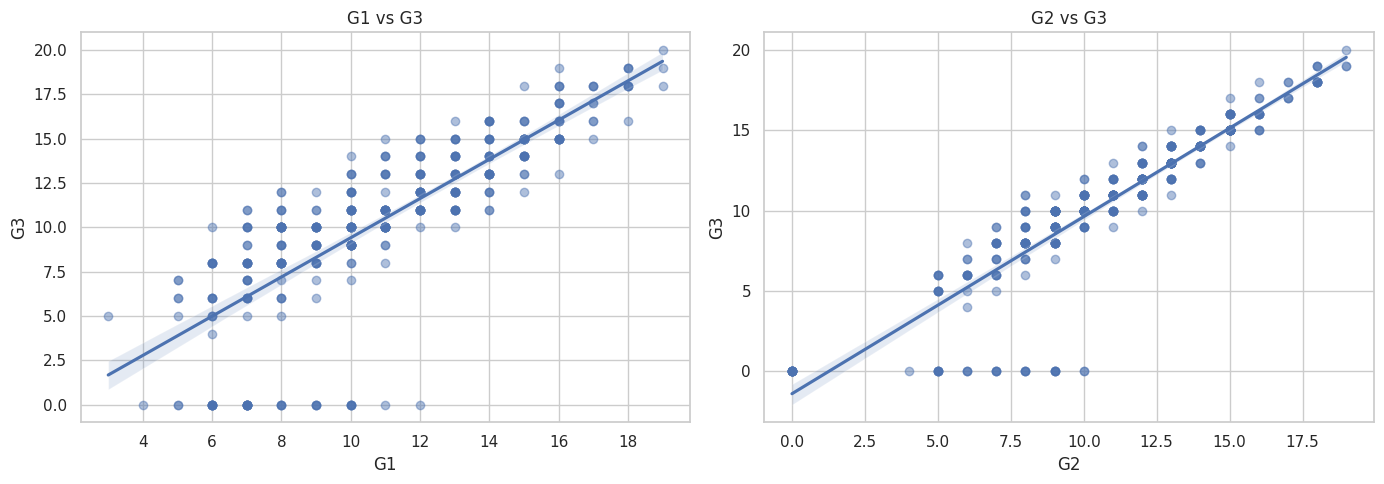

In [17]:
# ============================================================
# 16. G1/G2 against G3
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x="G1", y="G3", ax=axes[0], scatter_kws={"alpha": 0.45})
axes[0].set_title("G1 vs G3")

sns.regplot(data=df, x="G2", y="G3", ax=axes[1], scatter_kws={"alpha": 0.45})
axes[1].set_title("G2 vs G3")

plt.tight_layout()
plt.show()

### Interpretation

Use these plots to determine whether students with stronger earlier grades generally have stronger final grades. Do not interpret the regression line as proof of causation.

The project's own limitation section anticipates that `G1` and `G2` may be very important predictors and that the final model may rely heavily on previous academic performance. fileciteturn0file0L603-L608

# 7. Risk-threshold investigation

`Risk Status` is **not an original column** in the UCI dataset. The project requires it to be constructed from `G3` using a risk threshold justified using grading context and EDA. fileciteturn0file0L207-L218

We therefore examine multiple plausible thresholds before choosing one. This is an EDA/target-definition exercise, not model fitting.

In [18]:
# ============================================================
# 17. Candidate risk thresholds
# ============================================================
candidate_thresholds = [8, 9, 10, 11, 12]

threshold_analysis = []
for threshold in candidate_thresholds:
    at_risk = (df["G3"] < threshold)
    n_at_risk = int(at_risk.sum())
    n_not_risk = int((~at_risk).sum())

    threshold_analysis.append({
        "Threshold": f"G3 < {threshold}",
        "Threshold_value": threshold,
        "At_Risk_n": n_at_risk,
        "At_Risk_%": round(n_at_risk / len(df) * 100, 2),
        "Not_At_Risk_n": n_not_risk,
        "Not_At_Risk_%": round(n_not_risk / len(df) * 100, 2)
    })

threshold_df = pd.DataFrame(threshold_analysis)
print(threshold_df)

  Threshold  Threshold_value  At_Risk_n  At_Risk_%  Not_At_Risk_n  \
0    G3 < 8                8         70      17.72            325   
1    G3 < 9                9        102      25.82            293   
2   G3 < 10               10        130      32.91            265   
3   G3 < 11               11        186      47.09            209   
4   G3 < 12               12        233      58.99            162   

   Not_At_Risk_%  
0          82.28  
1          74.18  
2          67.09  
3          52.91  
4          41.01  


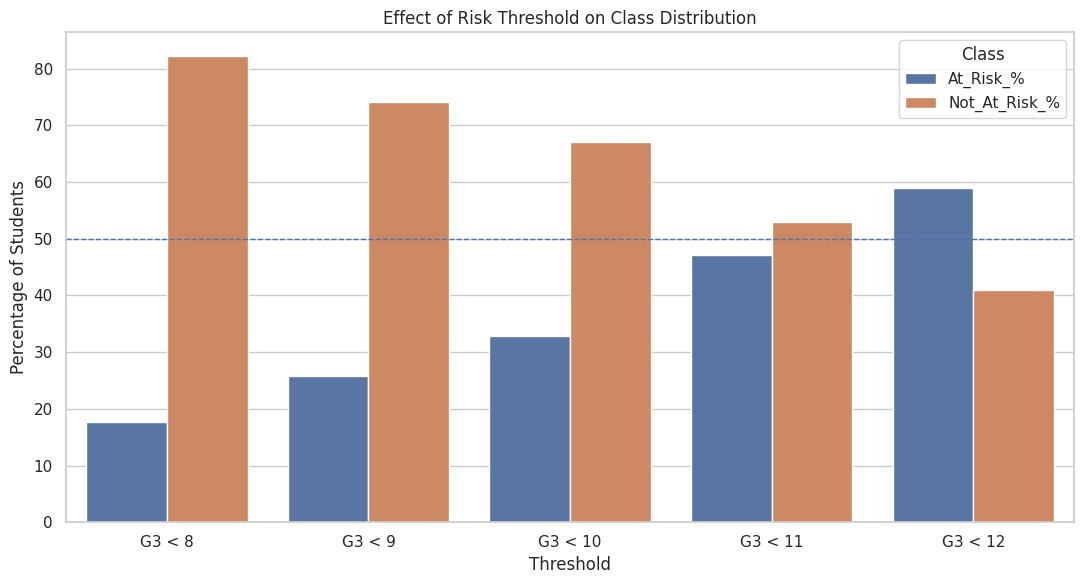

In [19]:
# ============================================================
# 18. Visual comparison of candidate class balances
# ============================================================
plot_df = threshold_df.melt(
    id_vars=["Threshold"],
    value_vars=["At_Risk_%", "Not_At_Risk_%"],
    var_name="Class",
    value_name="Percentage"
)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, x="Threshold", y="Percentage", hue="Class")
plt.axhline(50, linestyle="--", linewidth=1)
plt.title("Effect of Risk Threshold on Class Distribution")
plt.ylabel("Percentage of Students")
plt.tight_layout()
plt.show()

### Threshold decision framework

A threshold should not be chosen because it gives the highest model accuracy. It defines the **business meaning of the target itself**.

Evaluate candidate thresholds using:

1. educational/grading interpretation;
2. number of students labelled At Risk;
3. whether the positive class is large enough for meaningful model evaluation;
4. whether the resulting definition matches the project's business objective;
5. evidence from the `G3` distribution.

The project document explicitly states that a different threshold changes the number of At Risk students, class distribution, and potentially model performance. fileciteturn0file0L609-L615

## Candidate threshold to carry forward

For this dataset, **G3 < 10** is a strong candidate for further group discussion because it creates a substantial minority At-Risk group rather than an extremely rare class. However, the final report should describe it as an **evidence-based project decision**, not as a universal educational law.

The EDA evidence should be handed to the team member responsible for target preparation before the final target is frozen.

In [20]:
# ============================================================
# 19. Inspect G3 values around the candidate boundary
# ============================================================
g3_distribution = df["G3"].value_counts().sort_index().to_frame("count")
g3_distribution["percentage"] = (g3_distribution["count"] / len(df) * 100).round(2)

print(g3_distribution)

    count  percentage
G3                   
0      38        9.62
4       1        0.25
5       7        1.77
6      15        3.80
7       9        2.28
8      32        8.10
9      28        7.09
10     56       14.18
11     47       11.90
12     31        7.85
13     31        7.85
14     27        6.84
15     33        8.35
16     16        4.05
17      6        1.52
18     12        3.04
19      5        1.27
20      1        0.25
